In [1]:
import pandas as pd
pr_analyze = pd.read_excel("production_analytics_portfolio.xlsx.xlsx")

In [2]:
production = pd.read_excel("production_analytics_portfolio.xlsx.xlsx",sheet_name="Production")
products = pd.read_excel("production_analytics_portfolio.xlsx.xlsx",sheet_name="Products")
downtime = pd.read_excel("production_analytics_portfolio.xlsx.xlsx",sheet_name="Downtime")
quality = pd.read_excel("production_analytics_portfolio.xlsx.xlsx",sheet_name="Quality")
inventory = pd.read_excel("production_analytics_portfolio.xlsx.xlsx",sheet_name="Inventory")
lines = pd.read_excel("production_analytics_portfolio.xlsx.xlsx",sheet_name= "Lines")
machines = pd.read_excel("production_analytics_portfolio.xlsx.xlsx",sheet_name= "Machines")
materials = pd.read_excel("production_analytics_portfolio.xlsx.xlsx",sheet_name="Materials")
bom = pd.read_excel("production_analytics_portfolio.xlsx.xlsx",sheet_name="BOM")
monthly_plan = pd.read_excel("production_analytics_portfolio.xlsx.xlsx",sheet_name="Monthly_Plan")


In [3]:
production.shape

(3258, 18)

In [4]:
production.info()

<class 'pandas.DataFrame'>
RangeIndex: 3258 entries, 0 to 3257
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Date                         3258 non-null   datetime64[us]
 1   Month                        3258 non-null   int64         
 2   Product_ID                   3258 non-null   str           
 3   Line_ID                      3258 non-null   str           
 4   Machine_ID                   3258 non-null   str           
 5   Shift                        3258 non-null   str           
 6   Planned_Qty                  3258 non-null   int64         
 7   Actual_Qty                   3258 non-null   int64         
 8   Good_Qty                     3258 non-null   int64         
 9   Scrap_Qty                    3258 non-null   int64         
 10  Labor_Hours                  3258 non-null   float64       
 11  بررسی                        0 non-null      float64  

In [5]:
production.isna().sum()

Date                              0
Month                             0
Product_ID                        0
Line_ID                           0
Machine_ID                        0
Shift                             0
Planned_Qty                       0
Actual_Qty                        0
Good_Qty                          0
Scrap_Qty                         0
Labor_Hours                       0
بررسی                          3258
محموع تولید برنامه ریزی شده    3258
مجموع تولید واقعی              3258
اخلاف                          3258
Achevementکل                   3258
Achevement                     3258
production per labor hour      3258
dtype: int64

In [6]:
production.duplicated().sum()

np.int64(0)

In [7]:
planned = production["Planned_Qty"].sum()
actual = production["Actual_Qty"].sum()
achievement = actual/planned*100
print(achievement)

95.29747272430113


In [8]:
scrap_rate=(
    production["Scrap_Qty"].sum()
    /production["Actual_Qty"].sum()*100

)
print(scrap_rate)

2.114658759359127


In [9]:
good_production= production["Good_Qty"].sum()
print(good_production)

2796686


In [10]:
production.groupby("Month").agg(
    planned=("Planned_Qty","sum"),
    Actual=("Actual_Qty","sum")
)

,planned,Actual
Month,,
1,514475,497481
2,464520,445912
3,512120,491254
4,496598,463898
5,512100,479988
6,498277,478571


In [11]:
production.groupby("Product_ID").agg(
    Panned=("Planned_Qty","sum"),
    Actual=("Actual_Qty","sum")
)

,Panned,Actual
Product_ID,,
P001,563361,543293
P002,612585,589379
P003,482018,449059
P004,373916,347345
P005,537303,516300
P006,428907,411728


In [12]:
production.groupby("Line_ID").agg(
     Panned=("Planned_Qty","sum"),
     Actual=("Actual_Qty","sum")

)

,Panned,Actual
Line_ID,,
L01,1713249,1648972
L02,855934,796404
L03,428907,411728


In [13]:
production.groupby("Shift").agg(
     Panned=("Planned_Qty","sum"),
     Actual=("Actual_Qty","sum")
)

,Panned,Actual
Shift,,
Evening,998755,969438
Morning,997660,984999
Night,1001675,902667


In [14]:
production.groupby("Machine_ID").agg(
     Panned=("Planned_Qty","sum"),
     Actual=("Actual_Qty","sum")
)

,Panned,Actual
Machine_ID,,
M01,850854,820294
M02,862395,828678
M03,482018,449059
M04,373916,347345
M05,227189,218095
M06,201718,193633


In [15]:
product_analysis= production.groupby("Product_ID").agg(
    Planned=("Planned_Qty","sum"),
    Actual= ("Actual_Qty","sum"),
    Good=("Good_Qty","sum"),
    Scrap=("Scrap_Qty","sum"),
    Labor_Hours=("Labor_Hours","sum")
)
product_analysis["Achievement_%"]=(
    product_analysis["Actual"]
    /product_analysis["Planned"]*100
)
product_analysis["Scrap_Rate_%"]=(
    product_analysis["Scrap"]
    /product_analysis["Actual"]*100
)
product_analysis["Good_Productivity"]=(
    product_analysis["Good"]
    /product_analysis["Labor_Hours"]*100
)
product_analysis

,Planned,Actual,Good,Scrap,Labor_Hours,Achievement_%,Scrap_Rate_%,Good_Productivity
Product_ID,,,,,,,,
P001,563361,543293,535198,8095,4073.09,96.437808,1.489988,13139.852053
P002,612585,589379,578959,10420,4061.96,96.211791,1.767963,14253.193040
P003,482018,449059,431400,17659,4074.86,93.162289,3.932445,10586.866788
P004,373916,347345,340585,6760,4050.52,92.893859,1.946192,8408.426572
P005,537303,516300,507674,8626,4063.50,96.091032,1.670734,12493.515442
P006,428907,411728,402870,8858,4061.16,95.994703,2.151420,9920.072098


In [16]:
print(products.columns.tolist())

['Product_ID', 'Product', 'Category', 'Unit_Size', 'محموع تولید برنامه ریزی شده', 'مجموع تولید واقعی', 'اخلاف', 'Achevementکل', 'scrap', 'scrap rate']


In [17]:
product_analysis.sort_values(
    "Achievement_%"
)

,Planned,Actual,Good,Scrap,Labor_Hours,Achievement_%,Scrap_Rate_%,Good_Productivity
Product_ID,,,,,,,,
P004,373916,347345,340585,6760,4050.52,92.893859,1.946192,8408.426572
P003,482018,449059,431400,17659,4074.86,93.162289,3.932445,10586.866788
P006,428907,411728,402870,8858,4061.16,95.994703,2.151420,9920.072098
P005,537303,516300,507674,8626,4063.50,96.091032,1.670734,12493.515442
P002,612585,589379,578959,10420,4061.96,96.211791,1.767963,14253.193040
P001,563361,543293,535198,8095,4073.09,96.437808,1.489988,13139.852053


In [18]:
product_analysis.sort_values(
    "Scrap_Rate_%",
    ascending=False
)

,Planned,Actual,Good,Scrap,Labor_Hours,Achievement_%,Scrap_Rate_%,Good_Productivity
Product_ID,,,,,,,,
P003,482018,449059,431400,17659,4074.86,93.162289,3.932445,10586.866788
P006,428907,411728,402870,8858,4061.16,95.994703,2.151420,9920.072098
P004,373916,347345,340585,6760,4050.52,92.893859,1.946192,8408.426572
P002,612585,589379,578959,10420,4061.96,96.211791,1.767963,14253.193040
P005,537303,516300,507674,8626,4063.50,96.091032,1.670734,12493.515442
P001,563361,543293,535198,8095,4073.09,96.437808,1.489988,13139.852053


In [19]:
product_analysis.sort_values(
    "Good_Productivity"
)

,Planned,Actual,Good,Scrap,Labor_Hours,Achievement_%,Scrap_Rate_%,Good_Productivity
Product_ID,,,,,,,,
P004,373916,347345,340585,6760,4050.52,92.893859,1.946192,8408.426572
P006,428907,411728,402870,8858,4061.16,95.994703,2.151420,9920.072098
P003,482018,449059,431400,17659,4074.86,93.162289,3.932445,10586.866788
P005,537303,516300,507674,8626,4063.50,96.091032,1.670734,12493.515442
P001,563361,543293,535198,8095,4073.09,96.437808,1.489988,13139.852053
P002,612585,589379,578959,10420,4061.96,96.211791,1.767963,14253.193040


In [20]:
tables ={
    "Production":production,
    "downtime":downtime,
    "Quality":quality,
    "Inventory":inventory,
    "Products":products,
    "Lines":lines,
    "Machines":machines,
    "BOM":bom,
    "Monthly_Plan":monthly_plan,
}
for name, df in tables.items():
    print(name,"_>",df.shape)

Production _> (3258, 18)
downtime _> (1629, 6)
Quality _> (1086, 6)
Inventory _> (1448, 6)
Products _> (6, 10)
Lines _> (6, 7)
Machines _> (6, 7)
BOM _> (36, 3)
Monthly_Plan _> (36, 5)


In [21]:
quality_report =pd.DataFrame([{
     "Table":name,
     "Rows":df.shape[0],
     "Columns":df.shape[1],
     "Missing_Values":df.isna().sum().sum(),
     "Duplicate_Rows":df.duplicated().sum() 
}
for name,df in tables.items()
])
quality_report


,Table,Rows,Columns,Missing_Values,Duplicate_Rows
0,Production,3258,18,22806,0
1,downtime,1629,6,0,0
2,Quality,1086,6,0,0
3,Inventory,1448,6,0,0
4,Products,6,10,36,0
5,Lines,6,7,24,0
6,Machines,6,7,24,0
7,BOM,36,3,0,0
8,Monthly_Plan,36,5,0,0


In [22]:
production.missing = (
    production.isna()
    .sum()
    .sort_values(ascending=False)
)
production.missing

C:\Users\BEST\AppData\Local\Temp\ipykernel_8220\911132185.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  production.missing = (


production per labor hour      3258
اخلاف                          3258
محموع تولید برنامه ریزی شده    3258
مجموع تولید واقعی              3258
Achevementکل                   3258
Achevement                     3258
بررسی                          3258
Date                              0
Month                             0
Product_ID                        0
Scrap_Qty                         0
Good_Qty                          0
Actual_Qty                        0
Planned_Qty                       0
Shift                             0
Machine_ID                        0
Line_ID                           0
Labor_Hours                       0
dtype: int64

In [23]:
production.columns.tolist()

['Date',
 'Month',
 'Product_ID',
 'Line_ID',
 'Machine_ID',
 'Shift',
 'Planned_Qty',
 'Actual_Qty',
 'Good_Qty',
 'Scrap_Qty',
 'Labor_Hours',
 'بررسی',
 'محموع تولید برنامه ریزی شده',
 'مجموع تولید واقعی',
 'اخلاف',
 'Achevementکل',
 'Achevement',
 'production per labor hour']

In [24]:
production_clean = production[
   [ "Date",
    'Month',
    'Product_ID',
    'Line_ID',
    'Machine_ID',
    'Shift',
    'Planned_Qty',
    'Actual_Qty',
    'Good_Qty',
    'Scrap_Qty',
    'Labor_Hours'
]
].copy()

In [25]:
production_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 3258 entries, 0 to 3257
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         3258 non-null   datetime64[us]
 1   Month        3258 non-null   int64         
 2   Product_ID   3258 non-null   str           
 3   Line_ID      3258 non-null   str           
 4   Machine_ID   3258 non-null   str           
 5   Shift        3258 non-null   str           
 6   Planned_Qty  3258 non-null   int64         
 7   Actual_Qty   3258 non-null   int64         
 8   Good_Qty     3258 non-null   int64         
 9   Scrap_Qty    3258 non-null   int64         
 10  Labor_Hours  3258 non-null   float64       
dtypes: datetime64[us](1), float64(1), int64(5), str(4)
memory usage: 280.1 KB


In [26]:
production_clean.isna().sum()

Date           0
Month          0
Product_ID     0
Line_ID        0
Machine_ID     0
Shift          0
Planned_Qty    0
Actual_Qty     0
Good_Qty       0
Scrap_Qty      0
Labor_Hours    0
dtype: int64

In [27]:
production_clean["Product_ID"].unique()

<StringArray>
['P001', 'P002', 'P003', 'P004', 'P005', 'P006']
Length: 6, dtype: str

In [28]:
products["Product_ID"].unique()

<StringArray>
['P001', 'P002', 'P003', 'P004', 'P005', 'P006']
Length: 6, dtype: str

In [29]:
missing_products = set(
    production_clean["Product_ID"]
)- set(
    products["Product_ID"]
)
missing_products

set()

In [30]:
line_performance=(
    production_clean
    .groupby("Line_ID")
    .agg(
        Planned_Qty=("Planned_Qty","sum"),
        Actual_Qty = ("Actual_Qty","sum"),
        Scrap_Qty=("Scrap_Qty","sum"),
        Labor_Hours=("Labor_Hours","sum")
    )
    .reset_index()
)
line_performance

,Line_ID,Planned_Qty,Actual_Qty,Scrap_Qty,Labor_Hours
0,L01,1713249,1648972,27141,12198.55
1,L02,855934,796404,24419,8125.38
2,L03,428907,411728,8858,4061.16


In [31]:
line_performance["Achievement_%"]=(
    line_performance["Actual_Qty"]
    /line_performance["Planned_Qty"]
)*100

line_performance["Scrap_Qty_%"]=(
    line_performance["Scrap_Qty"]
    /line_performance["Actual_Qty"]
)*100



line_performance.round(2)

,Line_ID,Planned_Qty,Actual_Qty,Scrap_Qty,Labor_Hours,Achievement_%,Scrap_Qty_%
0,L01,1713249,1648972,27141,12198.55,96.25,1.65
1,L02,855934,796404,24419,8125.38,93.05,3.07
2,L03,428907,411728,8858,4061.16,95.99,2.15


In [32]:
line_performance["Production_per_Labor_Hour"]=(
    line_performance["Good_Qty"]
    /line_performance["Labor_Hours"]
)

KeyError: 'Good_Qty'

In [ ]:
line_performance.sort_values(
    "Scrap_Qty_%",
    ascending=False
).round(2)

,Line_ID,Planned_Qty,Actual_Qty,Scrap_Qty,Labor_Hours,Achievement_%,Scrap_Qty_%
1,L02,855934,796404,24419,8125.38,93.05,3.07
2,L03,428907,411728,8858,4061.16,95.99,2.15
0,L01,1713249,1648972,27141,12198.55,96.25,1.65


In [ ]:
line_performance.sort_values(
    "Achievement_%",
    ascending=False
).round(2)

,Line_ID,Planned_Qty,Actual_Qty,Scrap_Qty,Labor_Hours,Achievement_%,Scrap_Qty_%
0,L01,1713249,1648972,27141,12198.55,96.25,1.65
2,L03,428907,411728,8858,4061.16,95.99,2.15
1,L02,855934,796404,24419,8125.38,93.05,3.07


In [ ]:
line_monthly=(
    production_clean
    .groupby(["Month","Line_ID"])
    .agg(
        Planned_Qty=("Planned_Qty","sum"),
        Actual_Qty=("Actual_Qty","sum"),
        Good_Qty=("Good_Qty","sum"),
        Scrap_Qty=("Scrap_Qty","sum")
    )
    .reset_index()
)
line_monthly["Achievement_%"] = (
    line_monthly["Actual_Qty"]
    /line_monthly["Planned_Qty"]
)*100

line_monthly["Scrap_Rate_%"]=(
    line_monthly["Scrap_Qty"]
    /line_monthly["Actual_Qty"]
)*100

line_monthly.round(2)


,Month,Line_ID,Planned_Qty,Actual_Qty,Good_Qty,Scrap_Qty,Achievement_%,Scrap_Rate_%
0,1,L01,293700,284400,279700,4700,96.83,1.65
1,1,L02,146744,141975,137535,4440,96.75,3.13
2,1,L03,74031,71106,69546,1560,96.05,2.19
3,2,L01,265630,255118,250910,4208,96.04,1.65
4,2,L02,133234,128031,124127,3904,96.09,3.05
5,2,L03,65656,62763,61380,1383,95.59,2.20
6,3,L01,292115,279454,274861,4593,95.67,1.64
7,3,L02,146578,141012,136739,4273,96.20,3.03
8,3,L03,73427,70788,69295,1493,96.41,2.11
9,4,L01,284587,273760,269196,4564,96.20,1.67


In [ ]:
line_monthly.groupby("Line_ID")["Month"].count()

Line_ID
L01    6
L02    6
L03    6
Name: Month, dtype: int64

In [ ]:
line_performance.sort_values("Achievement_%")[[
    "Line_ID",
    "Achievement_%",
    "Scrap_Qty_%",
    ]].round(2)

,Line_ID,Achievement_%,Scrap_Qty_%
1,L02,93.05,3.07
2,L03,95.99,2.15
0,L01,96.25,1.65


In [ ]:
L02_monthly=(
    production_clean[production_clean["Line_ID"]=="L02"]
    .groupby("Month")
    .agg(
        Planned_Qty=("Planned_Qty","sum"),
        Actual_Qty=("Actual_Qty","sum"),
        Good_Qty=("Good_Qty","sum"),
        Scrap_Qty=("Scrap_Qty","sum")
    )
    .reset_index()
)
L02_monthly["Achievement_%"] = (
    L02_monthly["Actual_Qty"]
    /L02_monthly["Planned_Qty"]
)*100
L02_monthly["Scrap_Rate_%"]=(
    L02_monthly["Scrap_Qty"]
    /L02_monthly["Actual_Qty"]
)*100

L02_monthly.round(2)

,Month,Planned_Qty,Actual_Qty,Good_Qty,Scrap_Qty,Achievement_%,Scrap_Rate_%
0,1,146744,141975,137535,4440,96.75,3.13
1,2,133234,128031,124127,3904,96.09,3.05
2,3,146578,141012,136739,4273,96.20,3.03
3,4,140566,121573,117830,3743,86.49,3.08
4,5,146335,126776,122900,3876,86.63,3.06
5,6,142477,137037,132854,4183,96.18,3.05


In [ ]:
L02_monthly.sort_values("Achievement_%")[[
    "Month",
    "Achievement_%",
    "Scrap_Rate_%"
]].round(2)

,Month,Achievement_%,Scrap_Rate_%
3,4,86.49,3.08
4,5,86.63,3.06
1,2,96.09,3.05
5,6,96.18,3.05
2,3,96.20,3.03
0,1,96.75,3.13


In [ ]:
L02_monthly.sort_values("Scrap_Rate_%",ascending=False)[[
    "Month",
    "Achievement_%",
    "Scrap_Rate_%"
    ]].round(2)  


,Month,Achievement_%,Scrap_Rate_%
0,1,96.75,3.13
3,4,86.49,3.08
4,5,86.63,3.06
5,6,96.18,3.05
1,2,96.09,3.05
2,3,96.20,3.03


In [ ]:
downtime.columns

Index(['Date', 'Line_ID', 'Machine_ID', 'Shift', 'Downtime_Hours',
       'Downtime_Reason'],
      dtype='str')

In [ ]:
downtime["Date"]=pd.to_datetime(downtime["Date"])
L02_downtime=downtime[downtime["Line_ID"]=="L02"]
L02_downtime["Month"]=L02_downtime["Date"].dt.month
L02_downtime_monthly=(
    L02_downtime
    .groupby("Month")
    .agg(
        Downtime_Hours=("Downtime_Hours","sum")
    )
    .reset_index()
)
L02_downtime_monthly.round(2)

,Month,Downtime_Hours
0,1,119.89
1,2,129.53
2,3,169.31
3,4,247.94
4,5,251.55
5,6,166.63


In [ ]:
L02_problem_downtime=downtime[
    (downtime["Line_ID"]=="L02")&
    (downtime["Date"].dt.month.isin([4,5]))
]

downtime_by_reason=(
    L02_problem_downtime
    .groupby("Downtime_Reason")
    .agg(
        downtime_Hours=("Downtime_Hours","sum")
    )
    .reset_index()
    
    
)
downtime_by_reason.round(2)

,Downtime_Reason,downtime_Hours
0,Changeover,54.65
1,Machine Breakdown,146.40
2,Maintenance,61.98
3,Operator Unavailable,31.15
4,Planned Stop,24.21
5,Quality Issue,55.77
6,Raw Material Shortage,125.33


In [ ]:
L02_breakdown=downtime[
    (downtime["Line_ID"]=="L02")&
    (downtime["Downtime_Reason"]=="Machine Breakdown")&
    (downtime["Date"].dt.month.isin([4,5]))
]

breakdown_by_machine=(
    L02_breakdown
    .groupby("Machine_ID")
    .agg(
        Breakdown_Hours=("Downtime_Hours","sum")
    )
    .reset_index()
    )
 

breakdown_by_machine.round(2)

,Machine_ID,Breakdown_Hours
0,M03,48.87
1,M04,97.53


In [ ]:
downtime["Downtime_Reason"].unique()

<StringArray>
[    'Machine Breakdown',            'Changeover',           'Maintenance',
 'Raw Material Shortage',         'Quality Issue',  'Operator Unavailable',
          'Planned Stop']
Length: 7, dtype: str

In [ ]:
M04_monthly=(
    downtime[downtime["Machine_ID"]=="M04"]
    .groupby(downtime["Date"].dt.month)
    .agg(
        Downtime_Hours=("Downtime_Hours","sum")
    )
    .reset_index()
)
M04_monthly.round(2)

,Date,Downtime_Hours
0,1,53.21
1,2,72.77
2,3,90.27
3,4,186.14
4,5,184.93
5,6,94.79


In [ ]:
Shift_performance=(
    production_clean
    .groupby("Shift")
    .agg(
        Planned_Qty=("Planned_Qty","sum"),
        Actual_Qty = ("Actual_Qty","sum"),
        Scrap_Qty=("Scrap_Qty","sum"),
        Labor_Hours=("Labor_Hours","sum")
    )
    .reset_index()
)
Shift_performance["Achievement_%"] = (
    Shift_performance["Actual_Qty"]
    /Shift_performance["Planned_Qty"]
)*100
Shift_performance["Scrap_Rate_%"]=(
    Shift_performance["Scrap_Qty"]
    /Shift_performance["Actual_Qty"]
)*100
Shift_performance.round(2)


,Shift,Planned_Qty,Actual_Qty,Scrap_Qty,Labor_Hours,Achievement_%,Scrap_Rate_%
0,Evening,998755,969438,20502,8135.51,97.06,2.11
1,Morning,997660,984999,20765,8122.64,98.73,2.11
2,Night,1001675,902667,19151,8126.94,90.12,2.12


In [ ]:
import pandas as pd

In [ ]:
Overall_kpi= pd.DataFrame({
    "kpi":[
        "Total Planned Production",
        "Total Actual Production",
        "Total Good Production",
        "Total Scrap",
        "Achievement %",
        "Scrap Rate %",
        "Production Per Labor Hour"
    ],
    "value":[
        production_clean["Planned_Qty"].sum(),
        production_clean["Actual_Qty"].sum(),
        production_clean["Good_Qty"].sum(),
        production_clean["Scrap_Qty"].sum(),
        production_clean["Actual_Qty"].sum()
        /production_clean["Planned_Qty"].sum()*100,
        production_clean["Scrap_Qty"].sum()
        /production_clean["Actual_Qty"].sum()*100,
        production_clean["Good_Qty"].sum()
        /production_clean["Labor_Hours"].sum()
    ]
})

Overall_kpi.round(2)

,kpi,value
0,Total Planned Production,2998090.00
1,Total Actual Production,2857104.00
2,Total Good Production,2796686.00
3,Total Scrap,60418.00
4,Achievement %,95.30
5,Scrap Rate %,2.11
6,Production Per Labor Hour,114.69


In [ ]:
monthly_performance=(
    production_clean
    .groupby("Month")[["Planned_Qty","Actual_Qty"]]
    .sum()
    .reset_index()
    )
    

monthly_performance["Achievement_%"] = (
    monthly_performance["Actual_Qty"]
    /monthly_performance["Planned_Qty"]
)*100

monthly_performance.round(2)

,Month,Planned_Qty,Actual_Qty,Achievement_%
0,1,514475,497481,96.70
1,2,464520,445912,95.99
2,3,512120,491254,95.93
3,4,496598,463898,93.42
4,5,512100,479988,93.73
5,6,498277,478571,96.05


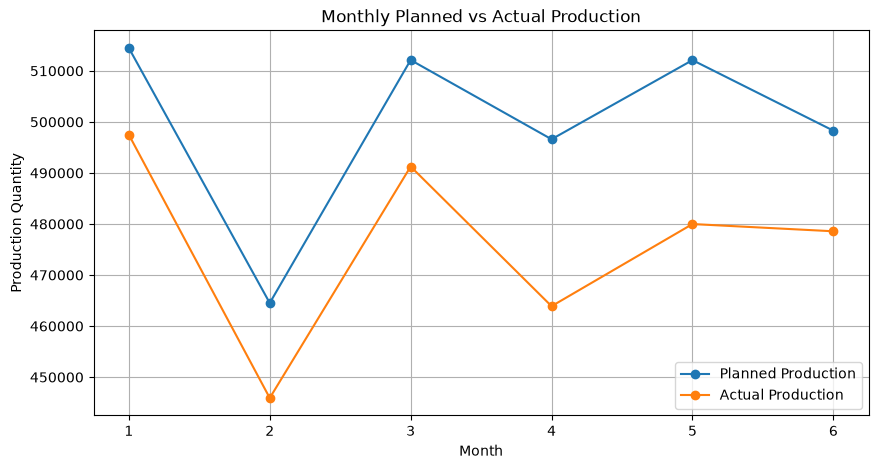

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(
    monthly_performance["Month"],
    monthly_performance["Planned_Qty"],
    marker="o",
    label="Planned Production"
)
plt.plot(
    monthly_performance["Month"],
    monthly_performance["Actual_Qty"],
    marker="o",
    label="Actual Production"
)
plt.title("Monthly Planned vs Actual Production")
plt.xlabel("Month")
plt.ylabel("Production Quantity")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
plt

<module 'matplotlib.pyplot' from 'c:\\Users\\BEST\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\site-packages\\matplotlib\\pyplot.py'>

In [ ]:
print(line_performance.columns.tolist())

['Line_ID', 'Planned_Qty', 'Actual_Qty', 'Scrap_Qty', 'Labor_Hours', 'Achievement_%', 'Scrap_Qty_%']


In [ ]:
print(type(line_performance))
print(type(line_performance["Achievement_%"]))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>


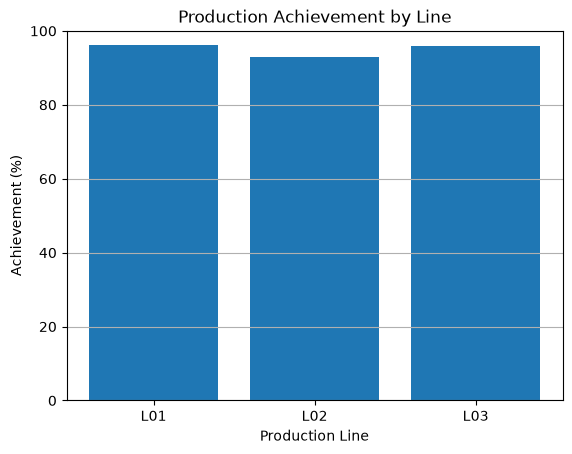

In [ ]:


plt.bar(
    line_performance["Line_ID"],
    line_performance["Achievement_%"]
)
plt.title("Production Achievement by Line")
plt.xlabel("Production Line")
plt.ylabel("Achievement (%)")
plt.ylim(0,100)
plt.grid(axis="y")

plt.show()

In [ ]:
line_performance["Scrap_Rate_%"]=(
    line_performance["Scrap_Qty"]
    /line_performance["Actual_Qty"]
)*100

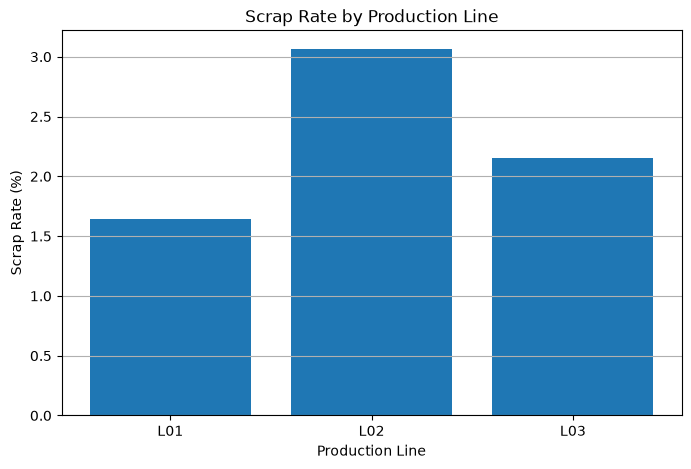

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    line_performance["Line_ID"],
    line_performance["Scrap_Rate_%"]
)

plt.title("Scrap Rate by Production Line")
plt.xlabel("Production Line")
plt.ylabel("Scrap Rate (%)")
plt.grid(axis="y")

plt.show()

In [ ]:
downtime_reason =(
    downtime
    .groupby("Downtime_Reason")["Downtime_Hours"]
    .sum()
    .sort_values(ascending=False)
)
downtime_reason

Downtime_Reason
Machine Breakdown        750.52
Raw Material Shortage    508.67
Changeover               436.73
Maintenance              426.50
Quality Issue            307.70
Operator Unavailable     198.62
Planned Stop             187.13
Name: Downtime_Hours, dtype: float64

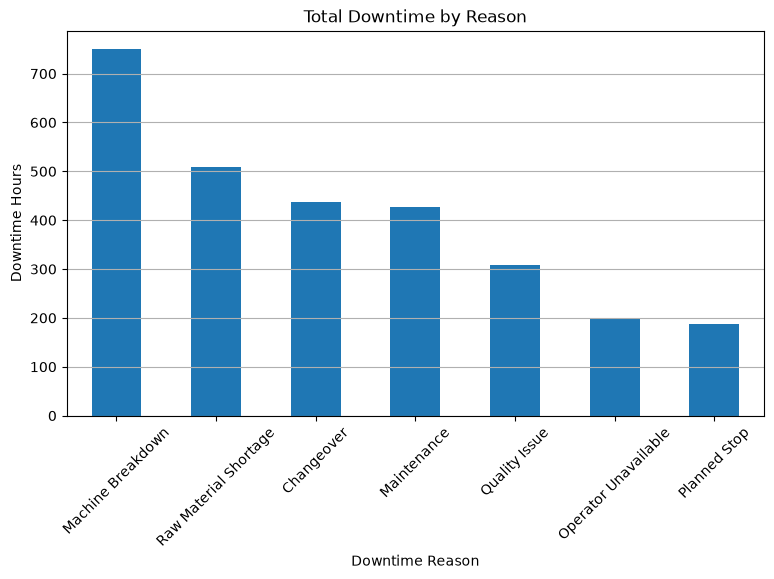

In [ ]:
plt.figure(figsize=(9,5))

downtime_reason.plot(kind="bar")

plt.title("Total Downtime by Reason")
plt.xlabel("Downtime Reason")
plt.ylabel("Downtime Hours")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

In [34]:
product_performance=(
    production_clean
    .groupby(["Product_ID"])
    .agg(
        Planned_Qty=("Planned_Qty","sum"),
        Actual_Qty=("Actual_Qty","sum"),
        Good_Qty=("Good_Qty","sum"),
        Scrap_Qty=("Scrap_Qty","sum"),
        Labor_Hours=("Labor_Hours","sum")
    )
    .reset_index()
)
product_performance["Achievement_%"] = (
    product_performance["Actual_Qty"]
    /product_performance["Planned_Qty"]
)*100

product_performance["Scrap_Rate_%"]=(
    product_performance["Scrap_Qty"]
    /product_performance["Actual_Qty"]
)*100



In [36]:
import matplotlib.pyplot as plt

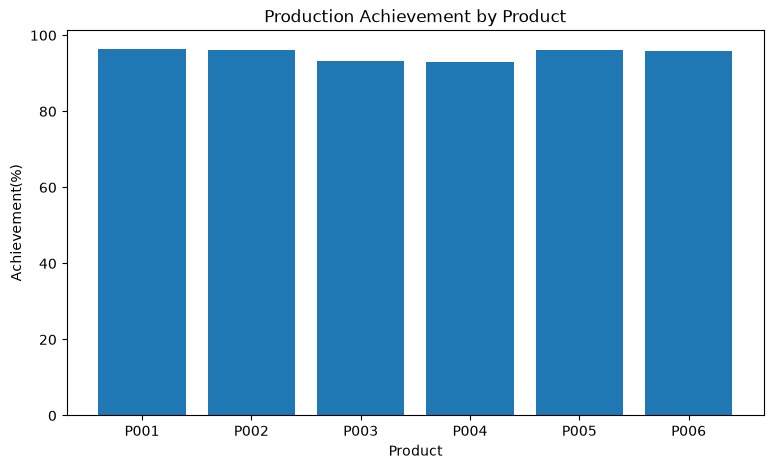

In [38]:
plt.figure(figsize=(9,5))

plt.bar(
    product_performance["Product_ID"],
    product_performance["Achievement_%"]
)
plt.title("Production Achievement by Product")
plt.xlabel("Product")
plt.ylabel("Achievement(%)")


plt.show()

In [39]:
with pd.ExcelWriter("product_analytics_clean.xlsx",engine="openpyxl")as writer:
    production_clean.to_excel(writer,sheet_name="Production",index=False)
    downtime.to_excel(writer,sheet_name="Downtime",index=False)
    quality.to_excel(writer,sheet_name="Quality",index=False)
    inventory.to_excel(writer,sheet_name="Inventory",index=False)
    products.to_excel(writer,sheet_name="Products",index=False)
    lines.to_excel(writer,sheet_name="Lines",index=False)
    machines.to_excel(writer,sheet_name="Machines",index=False)
    materials.to_excel(writer,sheet_name="Materials",index=False)
    bom.to_excel(writer,sheet_name="BOM",index=False)
    monthly_plan.to_excel(writer,sheet_name="Monthly_Plan",index=False)